# KAN Vision Transformer for Skin Lesion Classification

## 1. Setup and Imports

In [1]:
%pip install pykan

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'repr' attribute with value.*")
warnings.filterwarnings("ignore", message=".*The 'frozen' attribute with value.*")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary
import timm
from kan import KAN
from tqdm import tqdm
import copy

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedxc4/skin-ds")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-ds


## 2. KAN ViT Implementation

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class KANLinear(nn.Module):
    """Linear layer with learnable B-spline activations on each edge."""
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        """Build the layers."""
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        """Initialize the base and spline weights."""
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(0, 1)  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result

    @property
    def scaled_spline_weight(self):
        """Return spline weights scaled by per-edge standardization."""
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        """Run the forward pass."""
        assert x.dim() == 2 and x.size(1) == self.in_features

        base_output = F.linear(self.base_activation(x), self.base_weight)
        
        # Efficient implementation of spline computation
        x_norm = (x - self.grid[0, 0]) / (self.grid[0, -1] - self.grid[0, 0]) * 2 - 1
        # Clamp to avoid out of range
        x_norm = torch.clamp(x_norm, -1 + self.grid_eps, 1 - self.grid_eps)
        
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        return base_output + spline_output


class EfficientKAN(nn.Module):
    """Stack of KANLinear layers used as a transformer feedforward."""
    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        """Build the layers."""
        super(EfficientKAN, self).__init__()
        self.layers = nn.ModuleList()
        for in_features, out_features in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                KANLinear(
                    in_features,
                    out_features,
                    grid_size=grid_size,
                    spline_order=spline_order,
                    scale_noise=scale_noise,
                    scale_base=scale_base,
                    scale_spline=scale_spline,
                    base_activation=base_activation,
                    grid_eps=grid_eps,
                    grid_range=grid_range,
                )
            )

    def forward(self, x: torch.Tensor, update_grid=False):
        """Run the forward pass."""
        for layer in self.layers:
            if update_grid:
                pass
            x = layer(x)
        return x



In [5]:
class KANViTBlock(nn.Module):
    """Transformer block with self-attention and a KAN or MLP feedforward."""
    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
        use_kan=True
    ):
        """Build the layers."""
        super().__init__()

        # Robust import for timm versions
        try:
            from timm.layers import DropPath, Mlp, Attention
        except ImportError:
            from timm.models.layers import DropPath, Mlp
            from timm.models.vision_transformer import Attention

        self.norm1 = norm_layer(dim)
        
        # Use Attention from layers if available, else standard
        self.attn = Attention(
            dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop
        )

        self.drop_path = (
            DropPath(drop_path)
            if drop_path > 0.0 else nn.Identity()
        )

        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)

        if use_kan:
            self.mlp = EfficientKAN(
                layers_hidden=[dim, mlp_hidden_dim, dim],
                grid_size=5,
                spline_order=3
            )
        else:
            self.mlp = Mlp(
                in_features=dim,
                hidden_features=mlp_hidden_dim,
                act_layer=act_layer,
                drop=drop
            )

    def forward(self, x):
        """Run the forward pass."""
        x = x + self.drop_path(self.attn(self.norm1(x)))

        # Reshape for KAN (Batch, Tokens, Dim) -> (Batch * Tokens, Dim)
        B, N, C = x.shape
        x_reshaped = self.norm2(x).reshape(-1, C)
        x_kan = self.mlp(x_reshaped)
        x_kan = x_kan.reshape(B, N, C)

        x = x + self.drop_path(x_kan)
        return x

## 3. Model Creation

In [6]:
class EfficientKANViT(nn.Module):
    """EfficientNet backbone feeding KAN-ViT blocks and a linear head."""
    def __init__(self, num_classes, embed_dim=384, depth=4, num_heads=8, mlp_ratio=3.0, input_size=224):
        """Build the layers."""
        super().__init__()
        # 1. Feature Extractor (EfficientNet-B3 for High Accuracy)
        print("Initializing EfficientNet-B3 backbone...")
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True, features_only=True)
        
        # Freeze backbone weights
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # 2. Dynamic Channel Detection
        # To avoid hardcoding 320 or 384, we run a dummy pass
        with torch.no_grad():
            dummy = torch.zeros(1, 3, input_size, input_size)
            features = self.backbone(dummy)[-1]
            in_channels = features.shape[1]
            feat_map_size = features.shape[2]
            print(f"Backbone Output: {in_channels} channels, {feat_map_size}x{feat_map_size} map")
            
        # 3. Projection Layer
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)
        
        # Calculate number of tokens
        self.num_tokens = feat_map_size * feat_map_size
        
        # 4. Transformer Encoder (KAN-ViT)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, embed_dim))
        self.pos_drop = nn.Dropout(p=0.0)
        
        # Stack KANViTBlocks
        self.blocks = nn.ModuleList([
            KANViTBlock(
                dim=embed_dim, 
                num_heads=num_heads, 
                mlp_ratio=mlp_ratio,
                use_kan=(i % 2 == 0)
            ) for i in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        
        # 5. Classification Head
        self.head = nn.Linear(embed_dim, num_classes)
        
        self._init_weights()

    def _init_weights(self):
        """Initialize positional embedding and head weights."""
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.xavier_uniform_(self.head.weight)
        if self.head.bias is not None:
            nn.init.constant_(self.head.bias, 0)

    def forward(self, x):
        # x: (B, 3, H, W)
        """Run the forward pass."""
        features = self.backbone(x)[-1] 
        x = self.proj(features) 
        x = x.flatten(2).transpose(1, 2) 
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        for block in self.blocks:
            x = block(x)
            
        x = self.norm(x)
        x = x.mean(dim=1) 
        x = self.head(x) 
        return x

def create_kan_vit(num_classes=7, embed_dim=384, depth=4, num_heads=8, mlp_ratio=3.0):
    """Build an EfficientKANViT with the given depth, width, and heads."""
    model = EfficientKANViT(
        num_classes=num_classes, 
        embed_dim=embed_dim, 
        depth=depth, 
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        input_size=224 # Upgrade default to 224
    )
    return model

# Create the model
num_classes = 14
kan_vit_model = create_kan_vit(num_classes=num_classes, embed_dim=384, depth=4, num_heads=8, mlp_ratio=3.0)

# Print model summary with new input size
summary(kan_vit_model, input_size=(1, 3, 224, 224))


Initializing EfficientNet-B3 backbone...


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone Output: 384 channels, 7x7 map


Layer (type:depth-idx)                             Output Shape              Param #
EfficientKANViT                                    [1, 14]                   18,816
├─EfficientNetFeatures: 1-1                        [1, 24, 112, 112]         --
│    └─Conv2d: 2-1                                 [1, 40, 112, 112]         (1,080)
│    └─BatchNormAct2d: 2-2                         [1, 40, 112, 112]         80
│    │    └─Identity: 3-1                          [1, 40, 112, 112]         --
│    │    └─SiLU: 3-2                              [1, 40, 112, 112]         --
│    └─Sequential: 2-3                             --                        --
│    │    └─Sequential: 3-3                        [1, 24, 112, 112]         (3,504)
│    │    └─Sequential: 3-4                        [1, 32, 56, 56]           (48,118)
│    │    └─Sequential: 3-5                        [1, 48, 28, 28]           (110,912)
│    │    └─Sequential: 3-6                        [1, 96, 14, 14]           (638,700)
│

## 4. Data Loading and Preprocessing

In [7]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Upgraded to 224
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),   # Resize larger then crop
        transforms.CenterCrop(224), # Upgraded to 224
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

data_dir = '/kaggle/input/skin-ds/'

image_datasets = {
    x: datasets.ImageFolder(
        root=f"{data_dir}/{x}",
        transform=data_transforms[x]
    )
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=32, # Batch size might need reduction if OOM, but 32 usually fits B3 on T4
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print("Classes:", class_names)
print("Number of classes:", len(class_names))
print("Training size:", dataset_sizes['train'])
print("Validation size:", dataset_sizes['val'])

Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles', 'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 14
Training size: 29322
Validation size: 3660


## 5. Training the Model

In [8]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, LinearLR, SequentialLR
import csv
import copy
import math
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = kan_vit_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

scheduler_warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=3)
scheduler_main = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_main], milestones=[3])

num_epochs = 25

def train_model(model, criterion, optimizer, num_epochs, scheduler=None, reset_log=True):
    """Train the model, log per-epoch metrics, and keep the best checkpoint."""
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    scaler = torch.cuda.amp.GradScaler()
    
    csv_file = 'training_history.csv'
    header = ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'learning_rates']
    
    # LOGGING SETUP
    import os
    mode = 'w' if reset_log else 'a'
    should_write_header = reset_log or not os.path.exists(csv_file)
    
    if should_write_header:
        with open(csv_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(header)
        print(f"Created new training log: {csv_file}")
    else:
        print(f"Appending to existing training log: {csv_file}")

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-" * 10)
        
        metrics = {}

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            loss_nans = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train':
                        if device.type == 'cuda':
                            with torch.cuda.amp.autocast():
                                outputs = model(inputs)
                                loss = criterion(outputs, labels)
                        else:
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    if torch.isnan(loss):
                        loss_nans += 1
                        continue
                        
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        scaler.step(optimizer)
                        scaler.update()
                
                loss_val = loss.item()
                if not math.isnan(loss_val):
                    running_loss += loss_val * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()
            
            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            metrics[phase] = (epoch_loss, epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            if loss_nans > 0:
                print(f"Warning: {loss_nans} batches skipped due to NaN loss in {phase}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        current_lrs = [group['lr'] for group in optimizer.param_groups]
        
        with open(csv_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch, 
                metrics['train'][0], metrics['train'][1], 
                metrics['val'][0], metrics['val'][1],
                str(current_lrs)
            ])
                
        print(f"Current Learning Rates: {current_lrs}")

    print(f"Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model
# Start Training (Resets Log)
model_ft = train_model(model, criterion, optimizer, num_epochs, scheduler=scheduler, reset_log=True)

/tmp/ipykernel_106/3999550043.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Created new training log: training_history.csv
Epoch 0/24
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_106/3999550043.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [04:05<00:00,  3.74it/s]


train Loss: 2.1692 Acc: 0.3398


100%|██████████| 115/115 [00:25<00:00,  4.43it/s]


...

val Loss: 0.6519 Acc: 0.7678
Current Learning Rates: [7.938926261462366e-05]
Epoch 24/24
----------


100%|██████████| 917/917 [03:34<00:00,  4.28it/s]


train Loss: 0.5472 Acc: 0.8000


100%|██████████| 115/115 [00:20<00:00,  5.56it/s]

val Loss: 0.6801 Acc: 0.7598
Current Learning Rates: [7.269952498697734e-05]
Best val Acc: 0.7732


In [9]:
model_ft = train_model(model, criterion, optimizer, num_epochs=25, scheduler=scheduler)

# Save the model
torch.save(model_ft.state_dict(), 'efficientnetb3_kan_vit_skin_lesion_25_epochs.pth')
print('model saved')

/tmp/ipykernel_106/3999550043.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Created new training log: training_history.csv
Epoch 0/24
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_106/3999550043.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [03:24<00:00,  4.47it/s]


train Loss: 0.6046 Acc: 0.7782


100%|██████████| 115/115 [00:20<00:00,  5.61it/s]


...

val Loss: 0.5985 Acc: 0.7809
Current Learning Rates: [8.247240241650919e-05]
Epoch 24/24
----------


100%|██████████| 917/917 [03:09<00:00,  4.84it/s]


train Loss: 0.4711 Acc: 0.8265


100%|██████████| 115/115 [00:19<00:00,  5.93it/s]


val Loss: 0.6173 Acc: 0.7798
Current Learning Rates: [7.938926261462366e-05]
Best val Acc: 0.7839
model saved


## 6. Fine Tuning

In [10]:
# Load weights
try:
    model.load_state_dict(torch.load('/kaggle/working/efficientnetb3_kan_vit_skin_lesion_25_epochs.pth'))
    print("Loaded weights from local file.")
except FileNotFoundError:
    print("Could not find local weights. Proceeding with current model state...")

print("Unfreezing last 3 blocks of EfficientNet backbone...")
for name, param in model.backbone.named_parameters():
    if "blocks.4" in name or "blocks.5" in name or "blocks.6" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if "backbone" in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer_ft = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=1e-2)

scheduler_warmup = LinearLR(optimizer_ft, start_factor=0.01, end_factor=1.0, total_iters=5)
scheduler_main = CosineAnnealingWarmRestarts(optimizer_ft, T_0=5, T_mult=2)
scheduler_ft = SequentialLR(optimizer_ft, schedulers=[scheduler_warmup, scheduler_main], milestones=[5])

print("Starting Fine-tuning (Appends to Log)...")

def train_model(model, criterion, optimizer, num_epochs, scheduler=None, reset_log=True):
    """Train the model, log per-epoch metrics, and keep the best checkpoint."""
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    scaler = torch.cuda.amp.GradScaler()
    
    csv_file = 'training_history.csv'
    header = ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'learning_rates']
    
    # LOGGING SETUP
    import os
    mode = 'w' if reset_log else 'a'
    should_write_header = reset_log or not os.path.exists(csv_file)
    
    if should_write_header:
        with open(csv_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(header)
        print(f"Created new training log: {csv_file}")
    else:
        print(f"Appending to existing training log: {csv_file}")

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-" * 10)
        
        metrics = {}

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            loss_nans = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train':
                        if device.type == 'cuda':
                            with torch.cuda.amp.autocast():
                                outputs = model(inputs)
                                loss = criterion(outputs, labels)
                        else:
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    if torch.isnan(loss):
                        loss_nans += 1
                        continue
                        
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        scaler.step(optimizer)
                        scaler.update()
                
                loss_val = loss.item()
                if not math.isnan(loss_val):
                    running_loss += loss_val * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()
            
            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            metrics[phase] = (epoch_loss, epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            if loss_nans > 0:
                print(f"Warning: {loss_nans} batches skipped due to NaN loss in {phase}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        current_lrs = [group['lr'] for group in optimizer.param_groups]
        
        with open(csv_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch, 
                metrics['train'][0], metrics['train'][1], 
                metrics['val'][0], metrics['val'][1],
                str(current_lrs)
            ])
                
        print(f"Current Learning Rates: {current_lrs}")

    print(f"Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model
# Continue Training (Appends to Log)
model_ft = train_model(model, criterion, optimizer_ft, num_epochs=25, scheduler=scheduler_ft, reset_log=False)

torch.save(model_ft.state_dict(), 'efficientnetb3_kan_vit_skin_lesion_50_epochs.pth')
print('Fine-tuned model saved.')

/tmp/ipykernel_106/1977705864.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Loaded weights from local file.
Unfreezing last 3 blocks of EfficientNet backbone...
Starting Fine-tuning (Appends to Log)...
Appending to existing training log: training_history.csv
Epoch 0/24
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_106/1977705864.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [03:48<00:00,  4.02it/s]


train Loss: 0.4940 Acc: 0.8188


100%|██████████| 115/115 [00:19<00:00,  5.95it/s]


...

val Loss: 0.5066 Acc: 0.8374
Current Learning Rates: [9.045084971874738e-06, 9.045084971874738e-05]
Epoch 24/24
----------


100%|██████████| 917/917 [03:42<00:00,  4.13it/s]


train Loss: 0.2676 Acc: 0.9016


100%|██████████| 115/115 [00:19<00:00,  5.98it/s]


val Loss: 0.5034 Acc: 0.8347
Current Learning Rates: [8.535533905932739e-06, 8.535533905932738e-05]
Best val Acc: 0.8440
Fine-tuned model saved.


## 7. Evaluation & Visualization

In [ ]:
# Load model

import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load Model from Disk
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Re-create the model architecture 
loaded_model = create_kan_vit(
    num_classes=14, 
    embed_dim=384, 
    depth=4, 
    num_heads=8, 
    mlp_ratio=3.0
)

# Path to best saved model
checkpoint_path = '/kaggle/input/efficientnetb3/pytorch/default/1/efficientnetb3_kan_vit_skin_lesion_50_epochs.pth' 
if os.path.exists(checkpoint_path):
    print(f"Loading weights from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Handle dictionary vs direct state_dict save
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        loaded_model.load_state_dict(checkpoint['model_state_dict'])
    else:
        loaded_model.load_state_dict(checkpoint)
        
    print("Model loaded successfully!")
else:
    print(f"Checkpoint {checkpoint_path} not found. Please check the path.")
loaded_model = loaded_model.to(device)

Direct Feature Activation Visualization


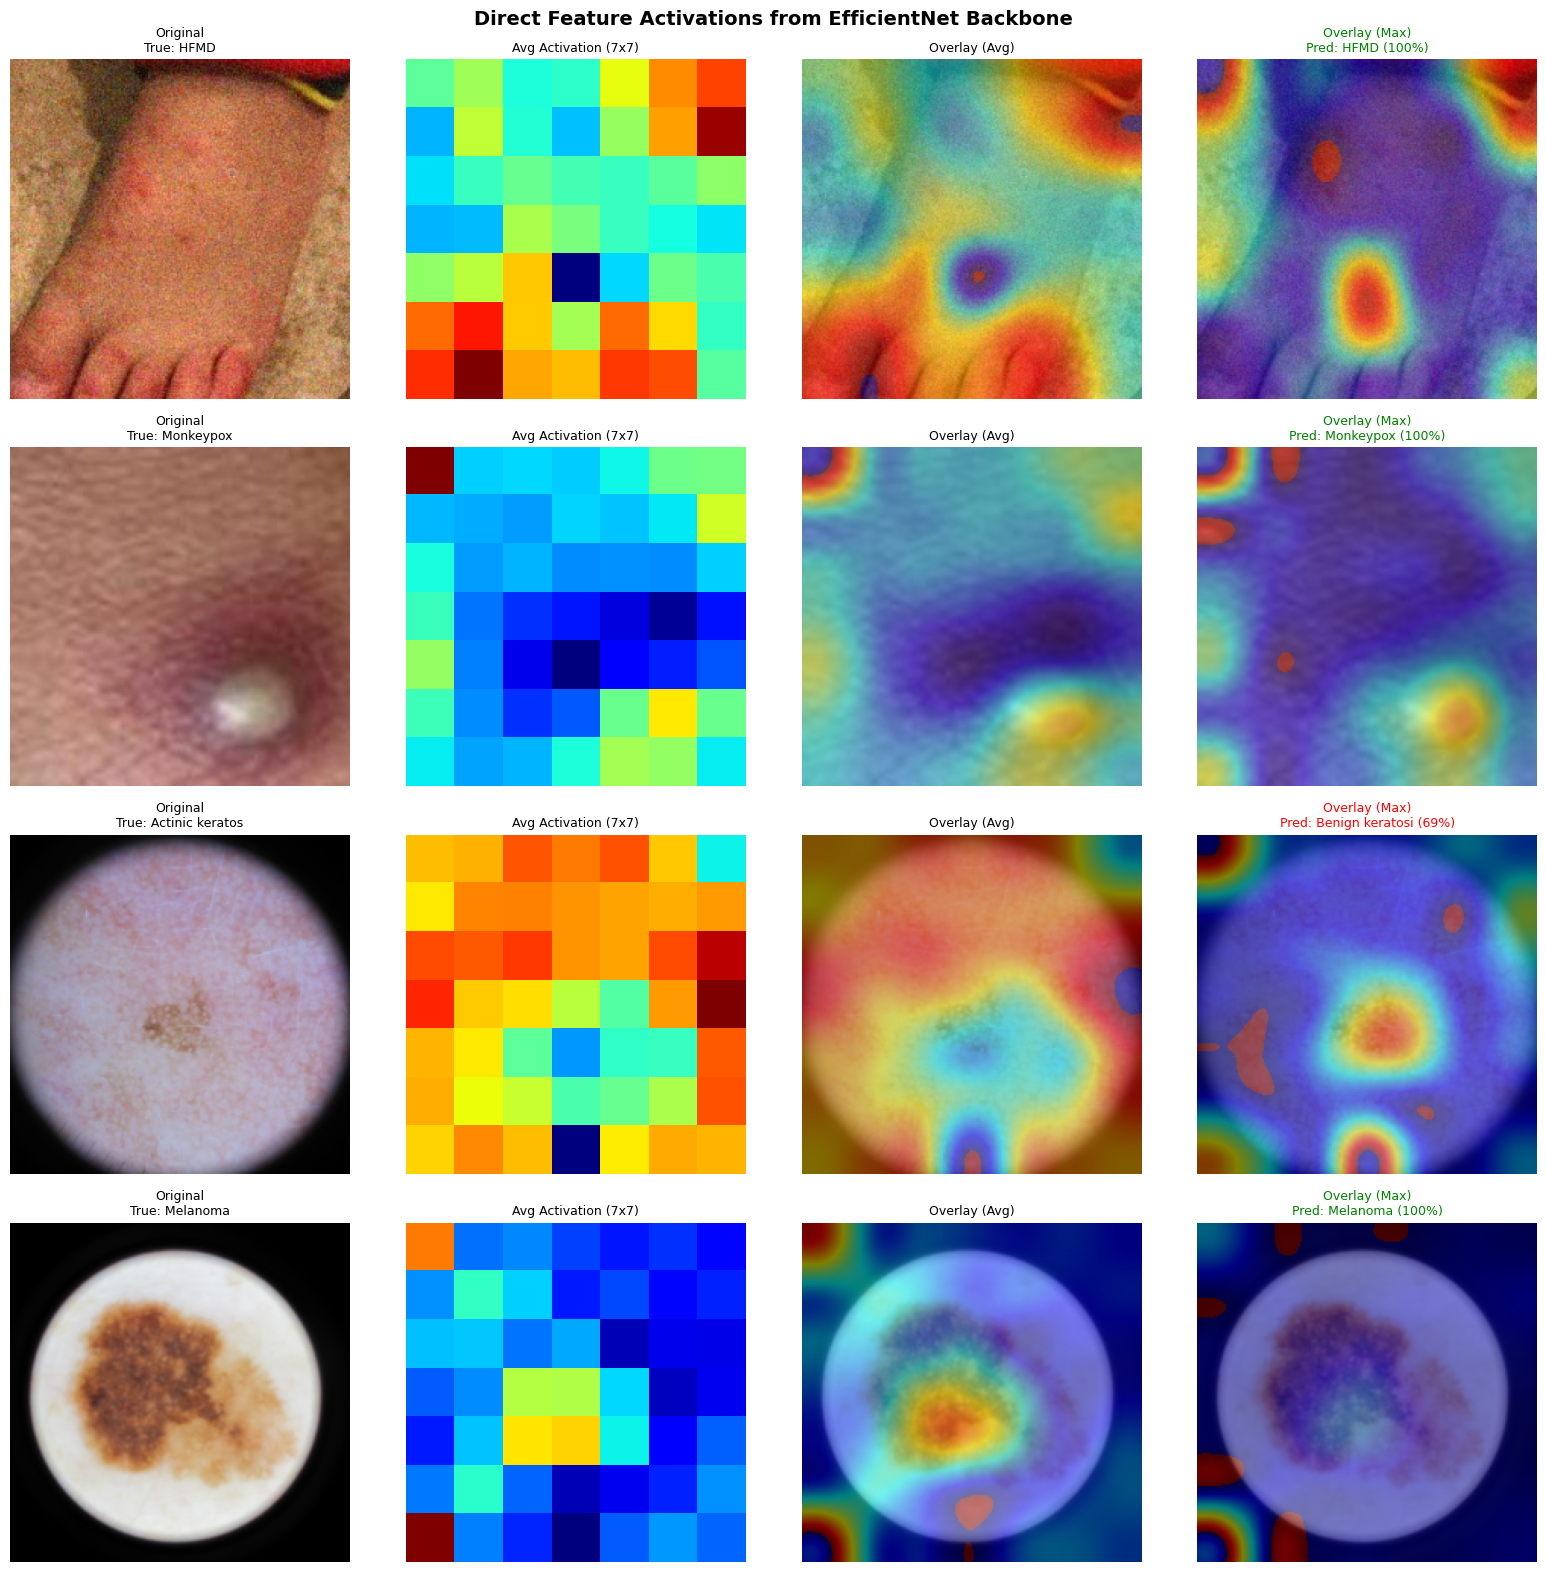


Note: If activations consistently highlight wrong areas,
the model may have learned spurious correlations (background, edges, etc.)


In [31]:
# === Direct Feature Map Visualization ===
# Shows what features the CNN backbone actually detects

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

def visualize_feature_activations(model, input_tensor, device):
    """
    Directly visualize what the backbone features look like.
    Returns the average activation across all channels.
    """
    model.eval()
    
    with torch.no_grad():
        # Get backbone features (this is what the model actually uses!)
        features = model.backbone(input_tensor)[-1]  # Shape: (1, 384, 7, 7)
        
        # Method 1: Average across channels
        avg_activation = features.mean(dim=1).squeeze()  # (7, 7)
        
        # Method 2: Max across channels
        max_activation = features.max(dim=1)[0].squeeze()  # (7, 7)
        
        # Normalize
        avg_activation = (avg_activation - avg_activation.min()) / (avg_activation.max() - avg_activation.min() + 1e-8)
        max_activation = (max_activation - max_activation.min()) / (max_activation.max() - max_activation.min() + 1e-8)
        
    return avg_activation.cpu().numpy(), max_activation.cpu().numpy()

def denorm(t):
    """Undo ImageNet normalization for display."""
    t = t.clone().cpu()
    for c, m, s in zip(t, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]):
        c.mul_(s).add_(m)
    return torch.clamp(t, 0, 1)

# === RUN ===
print("="*60)
print("Direct Feature Activation Visualization")
print("="*60)

all_inputs, all_labels = [], []
for inputs, labels in dataloaders['val']:
    all_inputs.append(inputs)
    all_labels.append(labels)
    if len(all_inputs) * inputs.shape[0] >= 32:
        break
all_inputs = torch.cat(all_inputs)
all_labels = torch.cat(all_labels)
indices = random.sample(range(len(all_inputs)), 4)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i, idx in enumerate(indices):
    inp = all_inputs[idx:idx+1].to(device)
    true_lbl = all_labels[idx].item()
    
    with torch.no_grad():
        out = loaded_model(inp)
        pred = out.argmax(dim=1).item()
        conf = F.softmax(out, dim=1)[0, pred].item()
    
    avg_act, max_act = visualize_feature_activations(loaded_model, inp, device)
    
    img = denorm(all_inputs[idx]).permute(1, 2, 0).numpy()
    
    # Upscale activations to image size with bicubic interpolation
    avg_act_up = cv2.resize(avg_act, (224, 224), interpolation=cv2.INTER_CUBIC)
    max_act_up = cv2.resize(max_act, (224, 224), interpolation=cv2.INTER_CUBIC)
    
    # Create overlays
    hm_avg = cv2.applyColorMap(np.uint8(255 * avg_act_up), cv2.COLORMAP_JET)
    hm_avg = cv2.cvtColor(hm_avg, cv2.COLOR_BGR2RGB) / 255.0
    overlay_avg = np.clip(0.5 * hm_avg + 0.5 * img, 0, 1)
    
    hm_max = cv2.applyColorMap(np.uint8(255 * max_act_up), cv2.COLORMAP_JET)
    hm_max = cv2.cvtColor(hm_max, cv2.COLOR_BGR2RGB) / 255.0
    overlay_max = np.clip(0.5 * hm_max + 0.5 * img, 0, 1)
    
    # Plot
    c = 'green' if true_lbl == pred else 'red'
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original\nTrue: {class_names[true_lbl][:15]}', fontsize=9)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(avg_act, cmap='jet')
    axes[i, 1].set_title('Avg Activation (7x7)', fontsize=9)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(overlay_avg)
    axes[i, 2].set_title('Overlay (Avg)', fontsize=9)
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(overlay_max)
    axes[i, 3].set_title(f'Overlay (Max)\nPred: {class_names[pred][:15]} ({conf:.0%})', fontsize=9, color=c)
    axes[i, 3].axis('off')

plt.suptitle('Direct Feature Activations from EfficientNet Backbone', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_activations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: If activations consistently highlight wrong areas,")
print("the model may have learned spurious correlations (background, edges, etc.)")

ROC-AUC Curve Analysis
Computing predictions for ROC-AUC...


100%|██████████| 115/115 [00:18<00:00,  6.31it/s]



AUC Scores by Class:
  Actinic keratoses                  : 0.9728
  Basal cell carcinoma               : 0.9870
  Benign keratosis-like lesions      : 0.9558
  Chickenpox                         : 0.9987
  Cowpox                             : 0.9997
  Dermatofibroma                     : 0.9902
  HFMD                               : 0.9997
  Healthy                            : 0.9998
  Measles                            : 0.9995
  Melanocytic nevi                   : 0.9755
  Melanoma                           : 0.9493
  Monkeypox                          : 0.9994
  Squamous cell carcinoma            : 0.9723
  Vascular lesions                   : 0.9985
--------------------------------------------------
  Micro-average                      : 0.9924
  Macro-average                      : 0.9856


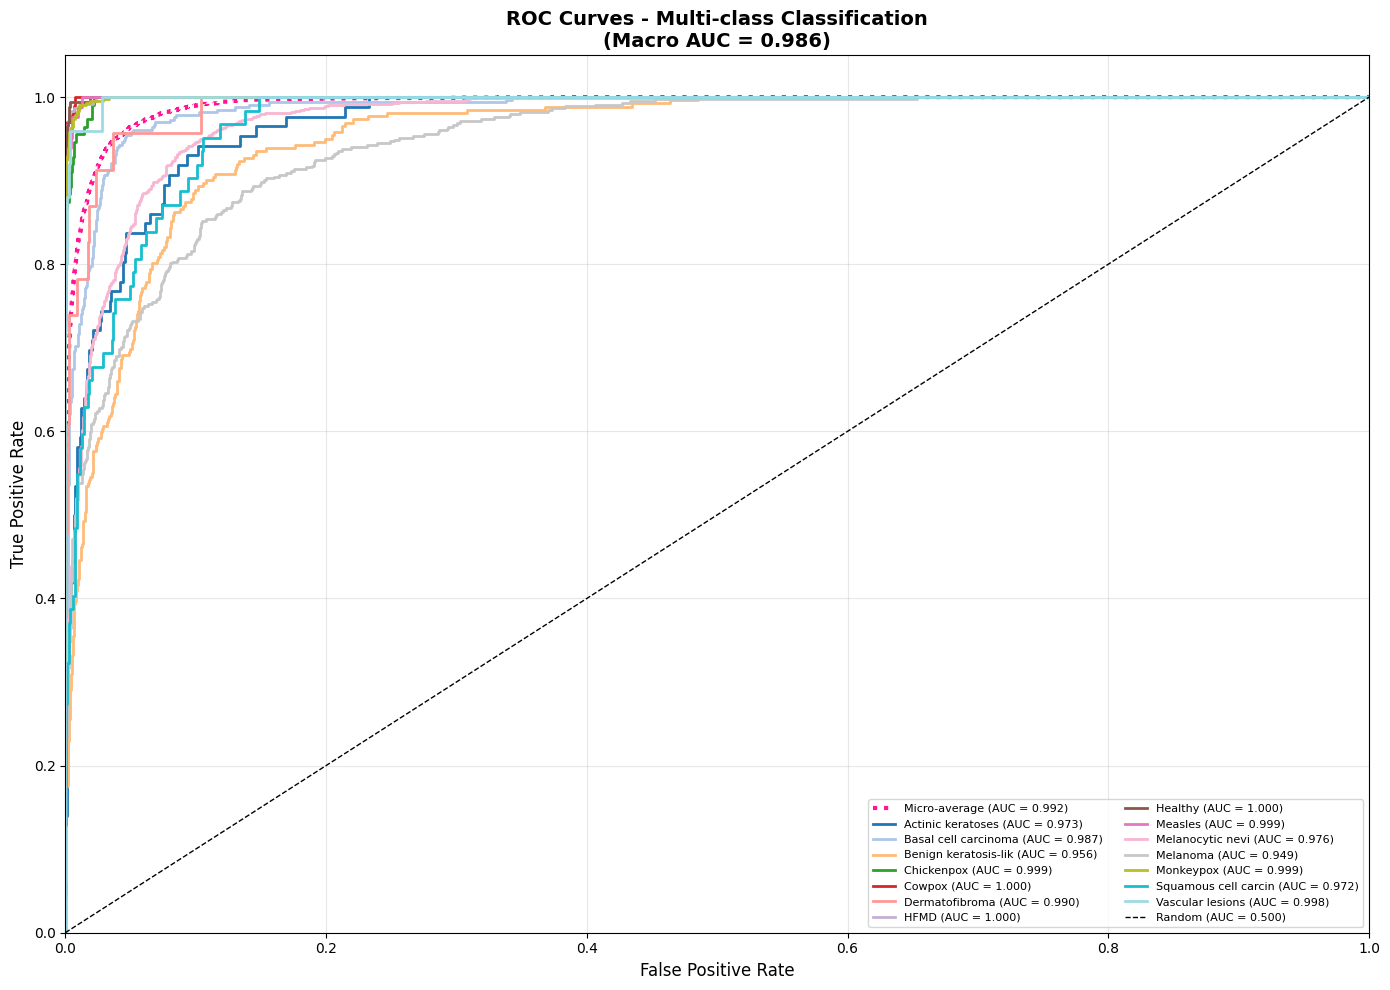


Saved to 'roc_auc_curves.png'


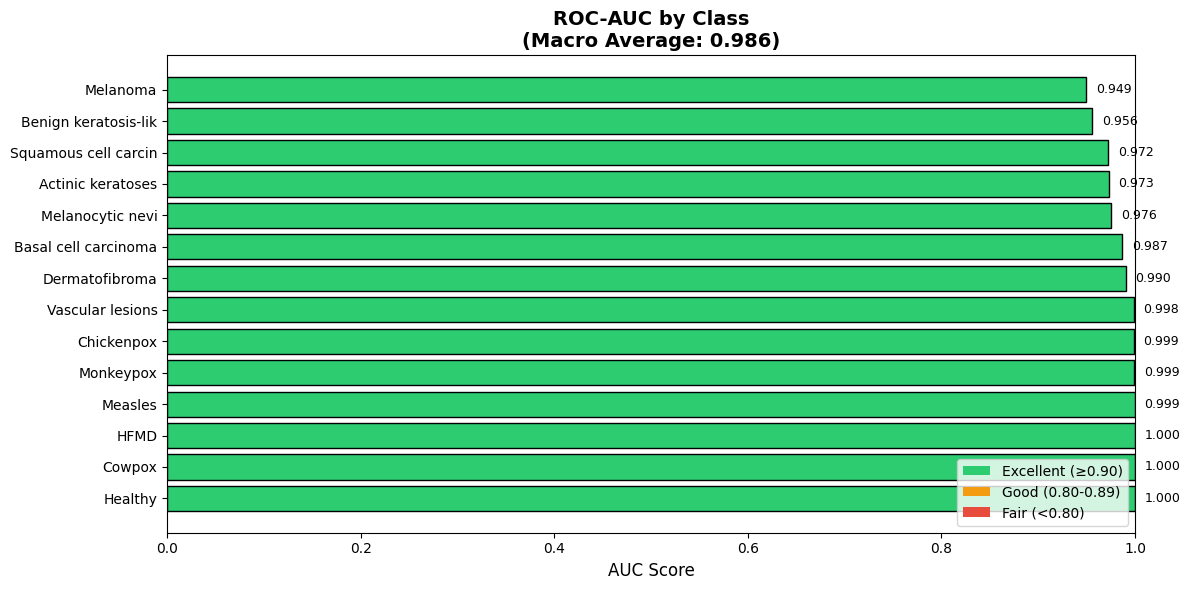


Saved to 'roc_auc_summary.png'


In [32]:
# === ROC-AUC Curve Generation ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from itertools import cycle

def compute_roc_auc(model, dataloader, class_names, device):
    """
    Compute ROC-AUC for multi-class classification.
    
    Returns:
        all_labels: True labels
        all_probs: Predicted probabilities for each class
        fpr: False positive rates (dict per class)
        tpr: True positive rates (dict per class)
        roc_auc: AUC scores (dict per class)
    """
    model.eval()
    all_labels = []
    all_probs = []
    
    print("Computing predictions for ROC-AUC...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(class_names)
    
    # Binarize labels for multi-class ROC
    labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    
    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Compute macro-average AUC
    roc_auc["macro"] = np.mean([roc_auc[i] for i in range(n_classes)])
    
    return all_labels, all_probs, fpr, tpr, roc_auc


def plot_roc_curves(fpr, tpr, roc_auc, class_names, figsize=(14, 10)):
    """
    Plot ROC curves for all classes.
    """
    n_classes = len(class_names)
    
    # Colors for each class
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    
    plt.figure(figsize=figsize)
    
    # Plot micro-average ROC curve
    plt.plot(
        fpr["micro"], tpr["micro"],
        label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
        color='deeppink', linestyle=':', linewidth=3
    )
    
    # Plot each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.plot(
            fpr[i], tpr[i], color=color, lw=2,
            label=f'{class_name[:20]} (AUC = {roc_auc[i]:.3f})'
        )
    
    # Diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - Multi-class Classification\n(Macro AUC = {roc_auc["macro"]:.3f})', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_auc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'roc_auc_curves.png'")
    return


def plot_roc_summary(roc_auc, class_names, figsize=(12, 6)):
    """
    Plot a bar chart showing AUC scores for each class.
    """
    n_classes = len(class_names)
    aucs = [roc_auc[i] for i in range(n_classes)]
    
    # Sort by AUC
    sorted_indices = np.argsort(aucs)[::-1]
    sorted_names = [class_names[i][:20] for i in sorted_indices]
    sorted_aucs = [aucs[i] for i in sorted_indices]
    
    # Colors based on AUC
    colors = ['#2ecc71' if a >= 0.9 else '#f39c12' if a >= 0.8 else '#e74c3c' for a in sorted_aucs]
    
    plt.figure(figsize=figsize)
    bars = plt.barh(range(n_classes), sorted_aucs, color=colors, edgecolor='black')
    plt.yticks(range(n_classes), sorted_names, fontsize=10)
    plt.xlabel('AUC Score', fontsize=12)
    plt.title(f'ROC-AUC by Class\n(Macro Average: {roc_auc["macro"]:.3f})', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    
    # Add value labels
    for i, (bar, auc_val) in enumerate(zip(bars, sorted_aucs)):
        plt.text(auc_val + 0.01, i, f'{auc_val:.3f}', va='center', fontsize=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Excellent (≥0.90)'),
        Patch(facecolor='#f39c12', label='Good (0.80-0.89)'),
        Patch(facecolor='#e74c3c', label='Fair (<0.80)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('roc_auc_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'roc_auc_summary.png'")


# === RUN ===
print("="*60)
print("ROC-AUC Curve Analysis")
print("="*60)

# Compute ROC-AUC
all_labels, all_probs, fpr, tpr, roc_auc = compute_roc_auc(
    loaded_model, dataloaders['val'], class_names, device
)

# Print AUC scores
print("\n" + "="*50)
print("AUC Scores by Class:")
print("="*50)
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {roc_auc[i]:.4f}")
print("-"*50)
print(f"  {'Micro-average':35s}: {roc_auc['micro']:.4f}")
print(f"  {'Macro-average':35s}: {roc_auc['macro']:.4f}")
print("="*50)

# Plot ROC curves
plot_roc_curves(fpr, tpr, roc_auc, class_names)

# Plot summary bar chart
plot_roc_summary(roc_auc, class_names)

Precision-Recall Curve Analysis
Computing predictions for PR curves...


100%|██████████| 115/115 [00:18<00:00,  6.23it/s]



Average Precision (AP) Scores by Class:
  Actinic keratoses                  : 0.5836
  Basal cell carcinoma               : 0.8829
  Benign keratosis-like lesions      : 0.6805
  Chickenpox                         : 0.9685
  Cowpox                             : 0.9909
  Dermatofibroma                     : 0.6635
  HFMD                               : 0.9961
  Healthy                            : 0.9963
  Measles                            : 0.9814
  Melanocytic nevi                   : 0.9527
  Melanoma                           : 0.7910
  Monkeypox                          : 0.9959
  Squamous cell carcinoma            : 0.5345
  Vascular lesions                   : 0.9202
--------------------------------------------------
  Micro-average                      : 0.9298
  Macro-average                      : 0.8527


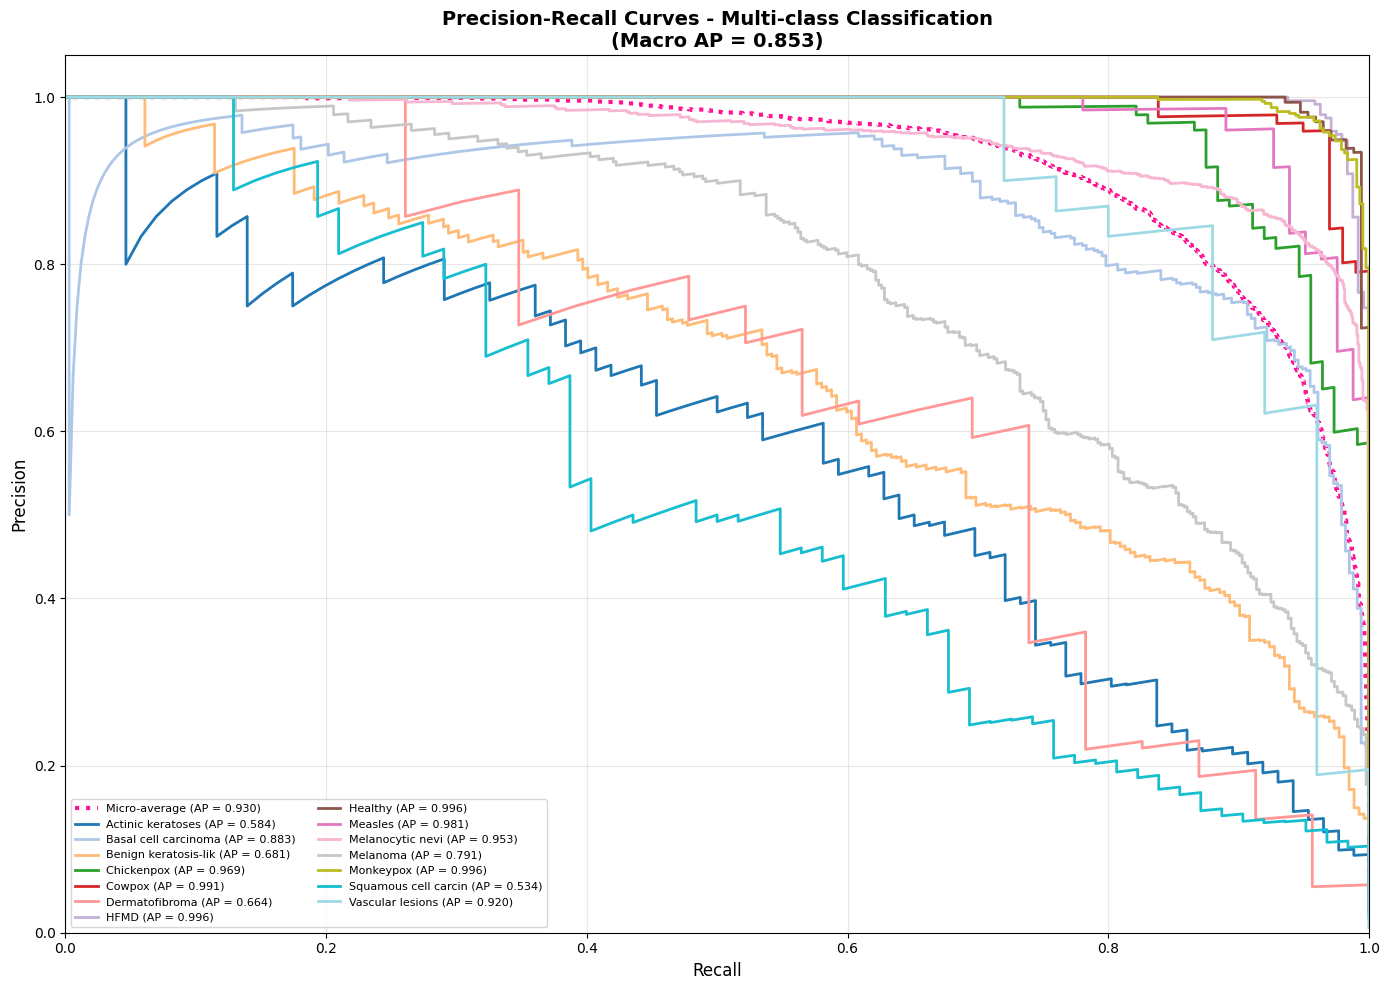


Saved to 'precision_recall_curves.png'


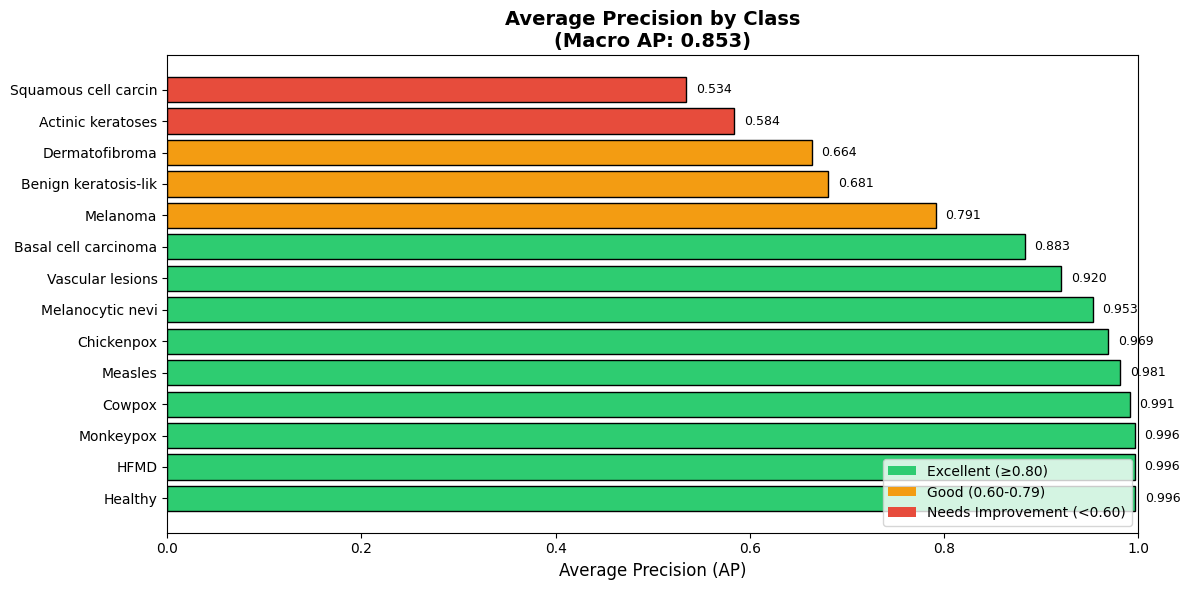


Saved to 'average_precision_summary.png'


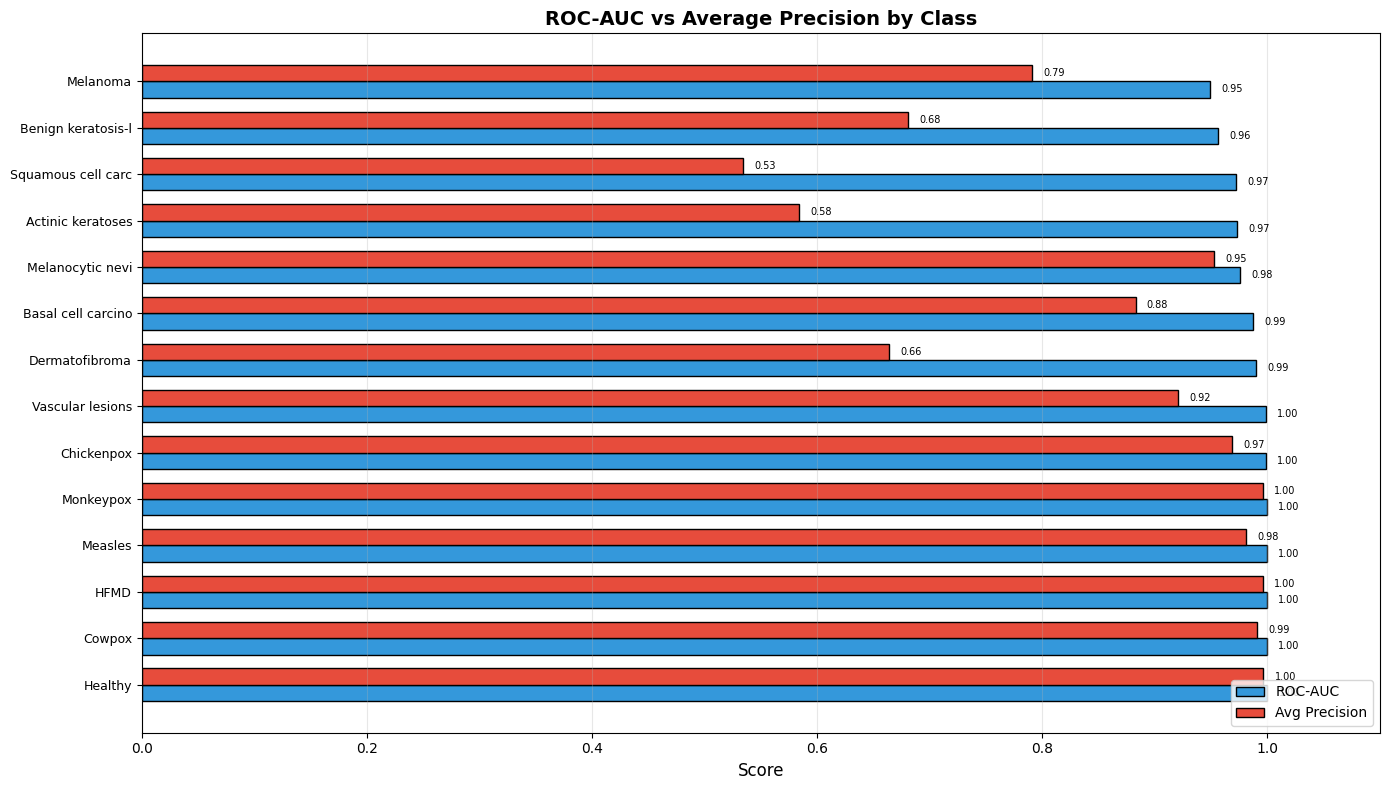


Saved to 'combined_metrics.png'


In [33]:
# === Precision-Recall Curve Generation ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

def compute_pr_curves(model, dataloader, class_names, device):
    """
    Compute Precision-Recall curves for multi-class classification.
    
    Returns:
        all_labels: True labels
        all_probs: Predicted probabilities for each class
        precision: Precision values (dict per class)
        recall: Recall values (dict per class)
        avg_precision: Average precision scores (dict per class)
    """
    model.eval()
    all_labels = []
    all_probs = []
    
    print("Computing predictions for PR curves...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(class_names)
    
    # Binarize labels for multi-class PR
    labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    
    # Compute PR curve and Average Precision for each class
    precision = {}
    recall = {}
    avg_precision = {}
    
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(labels_bin[:, i], all_probs[:, i])
        avg_precision[i] = average_precision_score(labels_bin[:, i], all_probs[:, i])
    
    # Compute micro-average PR curve
    precision["micro"], recall["micro"], _ = precision_recall_curve(
        labels_bin.ravel(), all_probs.ravel()
    )
    avg_precision["micro"] = average_precision_score(labels_bin, all_probs, average="micro")
    
    # Compute macro-average AP
    avg_precision["macro"] = np.mean([avg_precision[i] for i in range(n_classes)])
    
    return all_labels, all_probs, precision, recall, avg_precision


def plot_pr_curves(precision, recall, avg_precision, class_names, figsize=(14, 10)):
    """
    Plot Precision-Recall curves for all classes.
    """
    n_classes = len(class_names)
    
    # Colors for each class
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    
    plt.figure(figsize=figsize)
    
    # Plot micro-average PR curve
    plt.plot(
        recall["micro"], precision["micro"],
        label=f'Micro-average (AP = {avg_precision["micro"]:.3f})',
        color='deeppink', linestyle=':', linewidth=3
    )
    
    # Plot each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.plot(
            recall[i], precision[i], color=color, lw=2,
            label=f'{class_name[:20]} (AP = {avg_precision[i]:.3f})'
        )
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curves - Multi-class Classification\n(Macro AP = {avg_precision["macro"]:.3f})', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'precision_recall_curves.png'")
    return


def plot_ap_summary(avg_precision, class_names, figsize=(12, 6)):
    """
    Plot a bar chart showing Average Precision scores for each class.
    """
    n_classes = len(class_names)
    aps = [avg_precision[i] for i in range(n_classes)]
    
    # Sort by AP
    sorted_indices = np.argsort(aps)[::-1]
    sorted_names = [class_names[i][:20] for i in sorted_indices]
    sorted_aps = [aps[i] for i in sorted_indices]
    
    # Colors based on AP
    colors = ['#2ecc71' if a >= 0.8 else '#f39c12' if a >= 0.6 else '#e74c3c' for a in sorted_aps]
    
    plt.figure(figsize=figsize)
    bars = plt.barh(range(n_classes), sorted_aps, color=colors, edgecolor='black')
    plt.yticks(range(n_classes), sorted_names, fontsize=10)
    plt.xlabel('Average Precision (AP)', fontsize=12)
    plt.title(f'Average Precision by Class\n(Macro AP: {avg_precision["macro"]:.3f})', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    
    # Add value labels
    for i, (bar, ap_val) in enumerate(zip(bars, sorted_aps)):
        plt.text(ap_val + 0.01, i, f'{ap_val:.3f}', va='center', fontsize=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Excellent (≥0.80)'),
        Patch(facecolor='#f39c12', label='Good (0.60-0.79)'),
        Patch(facecolor='#e74c3c', label='Needs Improvement (<0.60)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('average_precision_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'average_precision_summary.png'")


def plot_combined_metrics(roc_auc, avg_precision, class_names, figsize=(14, 8)):
    """
    Plot combined ROC-AUC and Average Precision comparison.
    """
    n_classes = len(class_names)
    
    x = np.arange(n_classes)
    width = 0.35
    
    aucs = [roc_auc[i] for i in range(n_classes)]
    aps = [avg_precision[i] for i in range(n_classes)]
    
    # Sort by AUC
    sorted_indices = np.argsort(aucs)[::-1]
    sorted_names = [class_names[i][:18] for i in sorted_indices]
    sorted_aucs = [aucs[i] for i in sorted_indices]
    sorted_aps = [aps[i] for i in sorted_indices]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bars1 = ax.barh(x - width/2, sorted_aucs, width, label='ROC-AUC', color='#3498db', edgecolor='black')
    bars2 = ax.barh(x + width/2, sorted_aps, width, label='Avg Precision', color='#e74c3c', edgecolor='black')
    
    ax.set_xlabel('Score', fontsize=12)
    ax.set_title('ROC-AUC vs Average Precision by Class', fontsize=14, fontweight='bold')
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.set_xlim([0, 1.1])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar, val in zip(bars1, sorted_aucs):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=7)
    for bar, val in zip(bars2, sorted_aps):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=7)
    
    plt.tight_layout()
    plt.savefig('combined_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'combined_metrics.png'")


# === RUN ===
print("="*60)
print("Precision-Recall Curve Analysis")
print("="*60)

# Compute PR curves
all_labels, all_probs, precision, recall, avg_precision = compute_pr_curves(
    loaded_model, dataloaders['val'], class_names, device
)

# Print AP scores
print("\n" + "="*50)
print("Average Precision (AP) Scores by Class:")
print("="*50)
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {avg_precision[i]:.4f}")
print("-"*50)
print(f"  {'Micro-average':35s}: {avg_precision['micro']:.4f}")
print(f"  {'Macro-average':35s}: {avg_precision['macro']:.4f}")
print("="*50)

# Plot PR curves
plot_pr_curves(precision, recall, avg_precision, class_names)

# Plot AP summary bar chart
plot_ap_summary(avg_precision, class_names)

# If you have roc_auc from previous cell, plot combined comparison
try:
    plot_combined_metrics(roc_auc, avg_precision, class_names)
except NameError:
    print("\nNote: Run ROC-AUC cell first to generate combined metrics plot.")

FULL PERFORMANCE METRICS REPORT (with TTA)
Computing predictions with TTA (Original + HFlip + VFlip)...


100%|██████████| 115/115 [00:28<00:00,  4.00it/s]



OVERALL PERFORMANCE METRICS (with TTA)

Metric                                Value
---------------------------------------------
Accuracy (TTA)                       0.8544
Balanced Accuracy (TTA)              0.7911
Top-3 Accuracy (TTA)                 0.9790
Top-5 Accuracy (TTA)                 0.9967
Cohen Kappa                          0.8223
Matthews Corr. Coef.                 0.8226
---------------------------------------------
Precision (Macro)                    0.8388
Precision (Micro)                    0.8544
Precision (Weighted)                 0.8516
---------------------------------------------
Recall (Macro)                       0.7911
Recall (Micro)                       0.8544
Recall (Weighted)                    0.8544
---------------------------------------------
F1-Score (Macro)                     0.8115
F1-Score (Micro)                     0.8544
F1-Score (Weighted)                  0.8520

PER-CLASS PERFORMANCE METRICS (with TTA)

Class                       

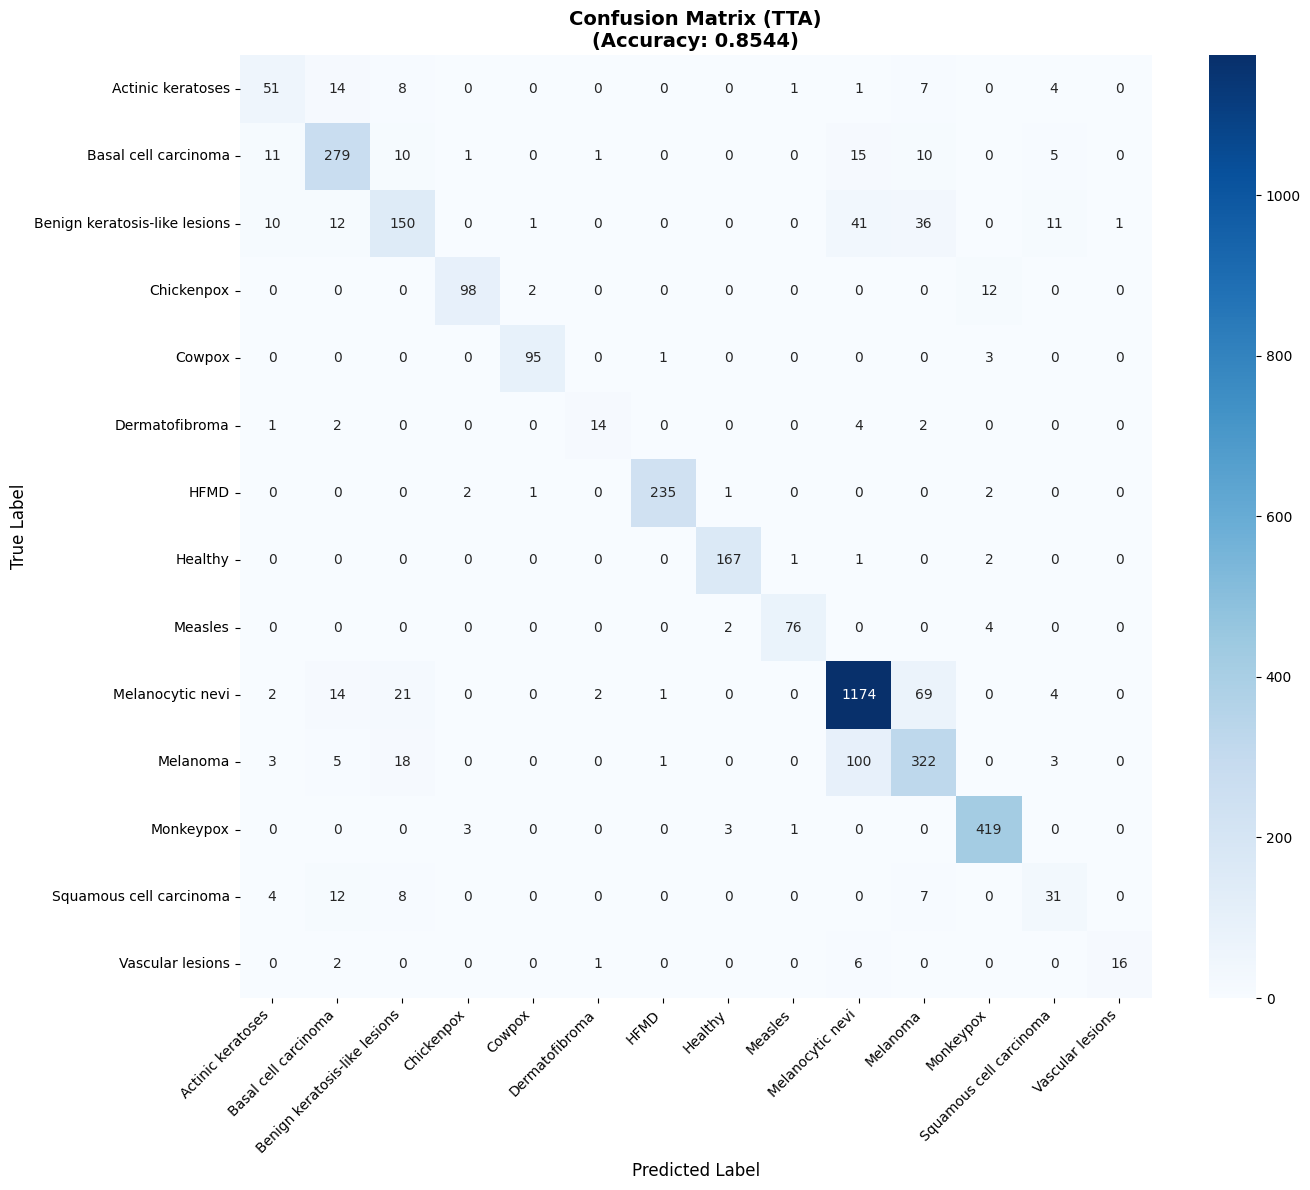


Saved confusion matrix to 'confusion_matrix_tta.png'


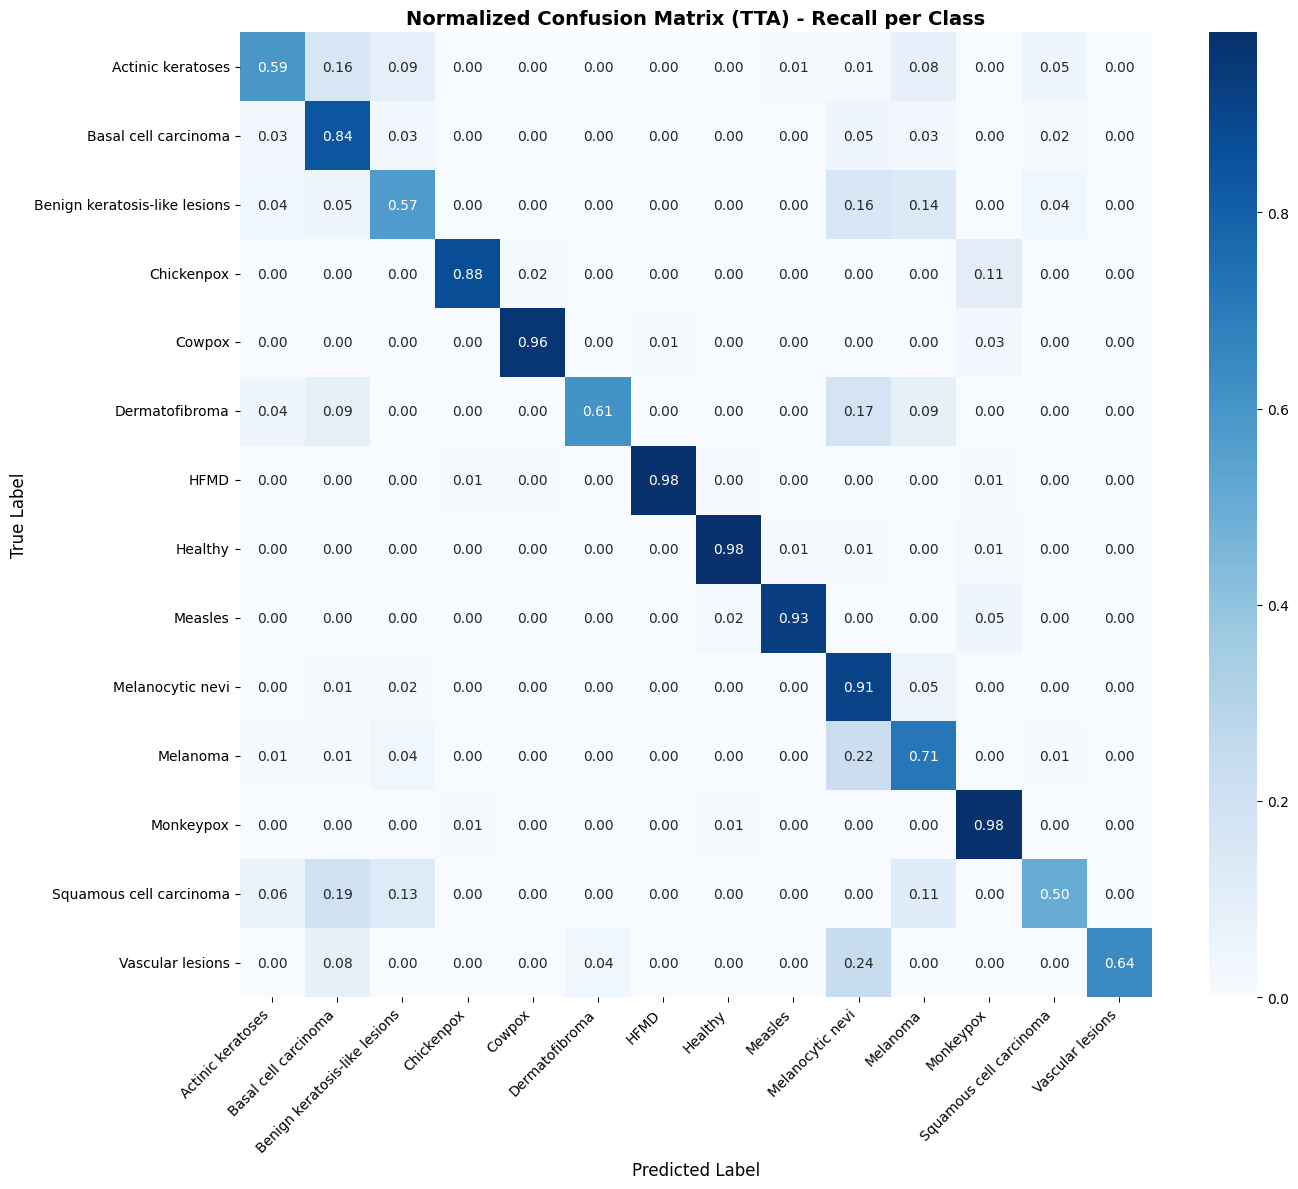

Saved normalized confusion matrix to 'confusion_matrix_normalized_tta.png'


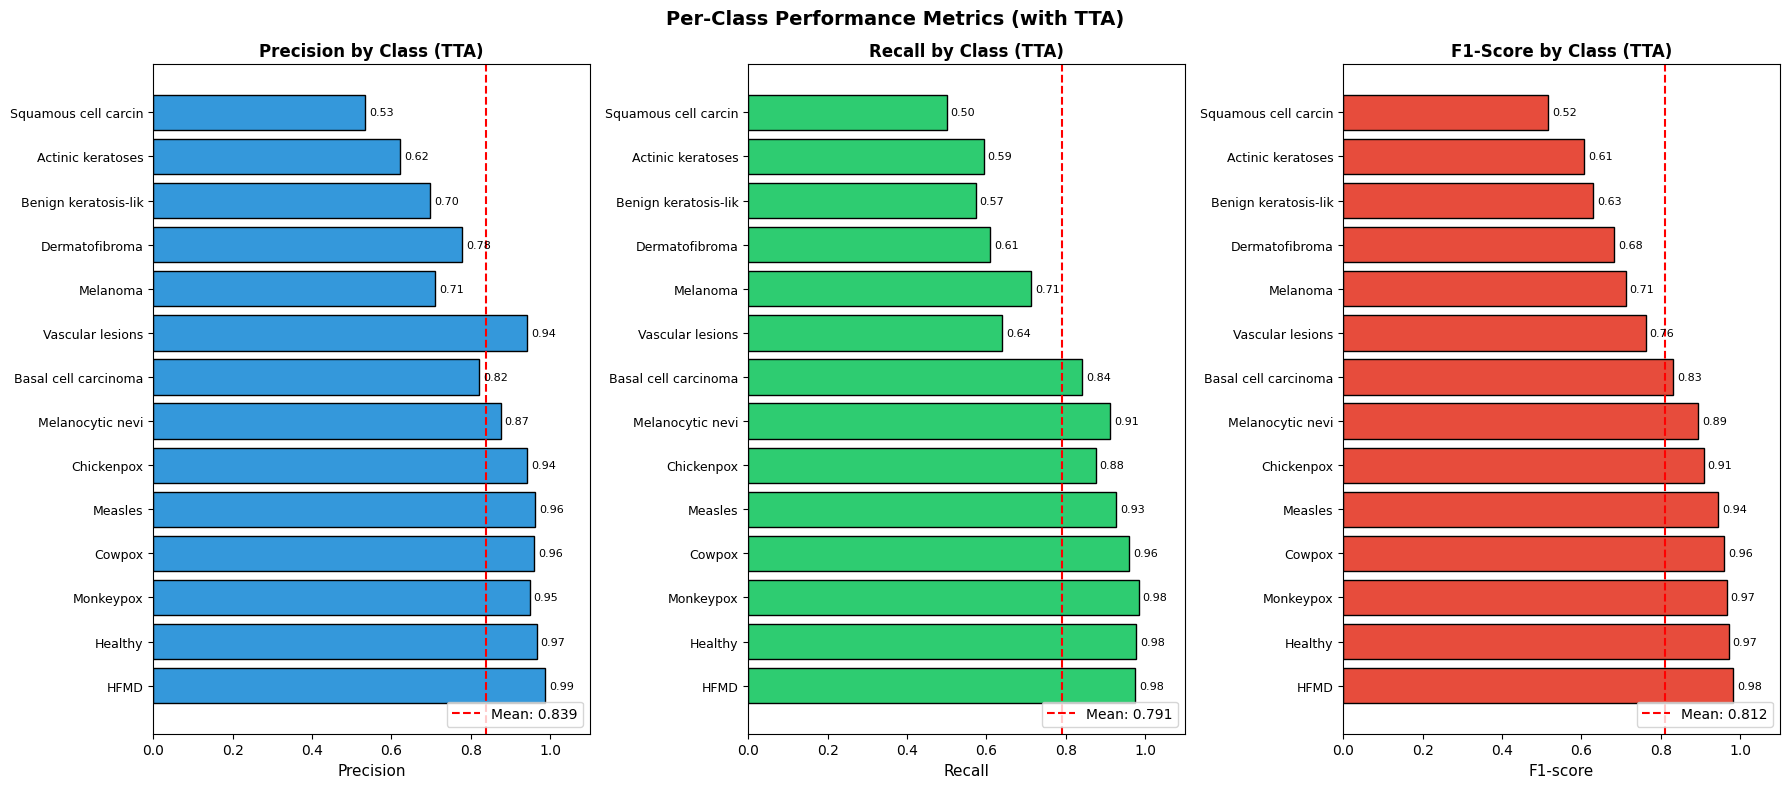

Saved metrics chart to 'metrics_by_class_tta.png'

Saved summary to 'performance_summary_tta.csv'
Saved per-class metrics to 'per_class_metrics_tta.csv'

REPORT COMPLETE!

Generated files:
  - confusion_matrix_tta.png
  - confusion_matrix_normalized_tta.png
  - metrics_by_class_tta.png
  - performance_summary_tta.csv
  - per_class_metrics_tta.csv


In [35]:
# === Full Performance Metrics Report with TTA ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
    top_k_accuracy_score
)
from tqdm import tqdm
import pandas as pd

def get_predictions_with_tta(model, dataloader, device):
    """
    Get all predictions and labels using Test Time Augmentation (TTA).
    
    TTA Strategy:
    1. Original image
    2. Horizontal flip
    3. Vertical flip
    
    Final prediction = average of softmax probabilities from all augmentations
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    print("Computing predictions with TTA (Original + HFlip + VFlip)...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            
            # 1. Original prediction
            outputs_orig = model(inputs)
            probs_orig = F.softmax(outputs_orig, dim=1)
            
            # 2. Horizontal flip
            inputs_hflip = torch.flip(inputs, dims=[3])
            outputs_hflip = model(inputs_hflip)
            probs_hflip = F.softmax(outputs_hflip, dim=1)
            
            # 3. Vertical flip
            inputs_vflip = torch.flip(inputs, dims=[2])
            outputs_vflip = model(inputs_vflip)
            probs_vflip = F.softmax(outputs_vflip, dim=1)
            
            # Average probabilities (TTA ensemble)
            avg_probs = (probs_orig + probs_hflip + probs_vflip) / 3.0
            
            # Get predictions from averaged probabilities
            _, preds = torch.max(avg_probs, 1)
            
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(avg_probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def generate_full_report_tta(model, dataloader, class_names, device):
    """Generate comprehensive performance metrics report with TTA."""
    
    # Get predictions with TTA
    y_true, y_pred, y_probs = get_predictions_with_tta(model, dataloader, device)
    n_classes = len(class_names)
    
    # 1. OVERALL METRICS
    print("\n" + "="*70)
    print("OVERALL PERFORMANCE METRICS (with TTA)")
    print("="*70)
    
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    top3_acc = top_k_accuracy_score(y_true, y_probs, k=3)
    top5_acc = top_k_accuracy_score(y_true, y_probs, k=5)
    
    # Macro/Micro/Weighted averages
    precision_macro = precision_score(y_true, y_pred, average='macro')
    precision_micro = precision_score(y_true, y_pred, average='micro')
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    
    recall_macro = recall_score(y_true, y_pred, average='macro')
    recall_micro = recall_score(y_true, y_pred, average='micro')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{'Metric':<30} {'Value':>12}")
    print("-"*45)
    print(f"{'Accuracy (TTA)':<30} {accuracy:>12.4f}")
    print(f"{'Balanced Accuracy (TTA)':<30} {balanced_acc:>12.4f}")
    print(f"{'Top-3 Accuracy (TTA)':<30} {top3_acc:>12.4f}")
    print(f"{'Top-5 Accuracy (TTA)':<30} {top5_acc:>12.4f}")
    print(f"{'Cohen Kappa':<30} {kappa:>12.4f}")
    print(f"{'Matthews Corr. Coef.':<30} {mcc:>12.4f}")
    print("-"*45)
    print(f"{'Precision (Macro)':<30} {precision_macro:>12.4f}")
    print(f"{'Precision (Micro)':<30} {precision_micro:>12.4f}")
    print(f"{'Precision (Weighted)':<30} {precision_weighted:>12.4f}")
    print("-"*45)
    print(f"{'Recall (Macro)':<30} {recall_macro:>12.4f}")
    print(f"{'Recall (Micro)':<30} {recall_micro:>12.4f}")
    print(f"{'Recall (Weighted)':<30} {recall_weighted:>12.4f}")
    print("-"*45)
    print(f"{'F1-Score (Macro)':<30} {f1_macro:>12.4f}")
    print(f"{'F1-Score (Micro)':<30} {f1_micro:>12.4f}")
    print(f"{'F1-Score (Weighted)':<30} {f1_weighted:>12.4f}")
    print("="*45)
    
    # 2. PER-CLASS METRICS
    print("\n" + "="*90)
    print("PER-CLASS PERFORMANCE METRICS (with TTA)")
    print("="*90)
    
    # Get sklearn classification report as dict
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # Create DataFrame for better formatting
    metrics_data = []
    for i, name in enumerate(class_names):
        metrics_data.append({
            'Class': name,
            'Precision': report_dict[name]['precision'],
            'Recall': report_dict[name]['recall'],
            'F1-Score': report_dict[name]['f1-score'],
            'Support': int(report_dict[name]['support'])
        })
    
    df_metrics = pd.DataFrame(metrics_data)
    df_metrics = df_metrics.sort_values('F1-Score', ascending=False)
    
    print(f"\n{'Class':<35} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-"*80)
    for _, row in df_metrics.iterrows():
        print(f"{row['Class']:<35} {row['Precision']:>10.4f} {row['Recall']:>10.4f} {row['F1-Score']:>10.4f} {row['Support']:>10}")
    print("-"*80)
    print(f"{'Macro Avg':<35} {precision_macro:>10.4f} {recall_macro:>10.4f} {f1_macro:>10.4f} {len(y_true):>10}")
    print(f"{'Weighted Avg':<35} {precision_weighted:>10.4f} {recall_weighted:>10.4f} {f1_weighted:>10.4f} {len(y_true):>10}")
    print("="*80)
    
    # 3. CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix (TTA)\n(Accuracy: {accuracy:.4f})', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved confusion matrix to 'confusion_matrix_tta.png'")
    
    # 4. NORMALIZED CONFUSION MATRIX
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Normalized Confusion Matrix (TTA) - Recall per Class', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_normalized_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved normalized confusion matrix to 'confusion_matrix_normalized_tta.png'")
    
    # 5. METRICS BAR CHART
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    
    # Sort by F1-score
    sorted_idx = np.argsort([report_dict[name]['f1-score'] for name in class_names])[::-1]
    sorted_names = [class_names[i] for i in sorted_idx]
    
    metrics_to_plot = ['precision', 'recall', 'f1-score']
    titles = ['Precision by Class (TTA)', 'Recall by Class (TTA)', 'F1-Score by Class (TTA)']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
        values = [report_dict[name][metric] for name in sorted_names]
        short_names = [n[:20] for n in sorted_names]
        
        bars = ax.barh(range(len(sorted_names)), values, color=color, edgecolor='black')
        ax.set_yticks(range(len(sorted_names)))
        ax.set_yticklabels(short_names, fontsize=9)
        ax.set_xlabel(metric.capitalize(), fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlim([0, 1.1])
        ax.axvline(x=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
        ax.legend(loc='lower right')
        
        for bar, val in zip(bars, values):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
    
    plt.suptitle('Per-Class Performance Metrics (with TTA)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('metrics_by_class_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved metrics chart to 'metrics_by_class_tta.png'")
    
    # 6. SUMMARY TABLE (Save to CSV)
    summary_data = {
        'Metric': ['Accuracy (TTA)', 'Balanced Accuracy (TTA)', 'Top-3 Accuracy (TTA)', 'Top-5 Accuracy (TTA)',
                   'Cohen Kappa', 'Matthews Corr. Coef.',
                   'Precision (Macro)', 'Precision (Weighted)',
                   'Recall (Macro)', 'Recall (Weighted)',
                   'F1-Score (Macro)', 'F1-Score (Weighted)'],
        'Value': [accuracy, balanced_acc, top3_acc, top5_acc,
                  kappa, mcc,
                  precision_macro, precision_weighted,
                  recall_macro, recall_weighted,
                  f1_macro, f1_weighted]
    }
    df_summary = pd.DataFrame(summary_data)
    df_summary.to_csv('performance_summary_tta.csv', index=False)
    print("\nSaved summary to 'performance_summary_tta.csv'")
    
    # Save per-class metrics
    df_metrics.to_csv('per_class_metrics_tta.csv', index=False)
    print("Saved per-class metrics to 'per_class_metrics_tta.csv'")
    
    # 7. RETURN RESULTS
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'top3_accuracy': top3_acc,
        'top5_accuracy': top5_acc,
        'kappa': kappa,
        'mcc': mcc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'per_class_report': report_dict,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs
    }


# === RUN ===
print("="*70)
print("FULL PERFORMANCE METRICS REPORT (with TTA)")
print("="*70)

results_tta = generate_full_report_tta(loaded_model, dataloaders['val'], class_names, device)

print("\n" + "="*70)
print("REPORT COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  - confusion_matrix_tta.png")
print("  - confusion_matrix_normalized_tta.png")
print("  - metrics_by_class_tta.png")
print("  - performance_summary_tta.csv")
print("  - per_class_metrics_tta.csv")